# 01 — Feature Engineering & EDA

**Pipeline:** **`01_features`** → `02_clv_bgnbd` → `03_clv_modeling` → `04_churn` → `05_segmentation` → `06_evaluation`

| | |
|---|---|
| **Depends on** | `data/features/feature_table_v2.parquet` (pre-built upstream — canonical customer-grain table) |
| **Produces** | Visual sanity-check figures in `docs/figures/` · confirms class balance, distributions, and BG/NBD invariants before downstream models |

---

**Owner:** Juan (D2)

Visual sanity check on `feature_table_v2.parquet`. Includes: class balance, one figure per BG/NBD input, recency-vs-tenure invariant scatter, feature correlation heatmap, revenue Pareto, and days-since-last-order CDF. This notebook never re-derives features — it only reads and visualises.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from src.features.build import class_balance

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

FEATURES_PATH = "../data/features/feature_table_v2.parquet"
CHURN_WINDOW_DAYS = 299

## Rebuild behavioural features — temporal filter

`feature_table_v2.parquet` is the upstream canonical table, but its behavioural
columns (`avg_product_price`, `avg_num_sku_per_order`, `top_product_type`,
`price_bucket`) were aggregated from **all** orders. Including post-split orders
leaks the label into training.

This section recomputes those columns using **only orders on or before `split_date`
= `max_order_date − 299d`** (the same cutoff notebook 04 uses), then overwrites
the parquet so downstream notebooks load clean features.

In [2]:
import sys
sys.path.insert(0, str(Path.cwd().parent))

from src.features.behavioral import load_order_line_attributes, build_behavioral_features

ORDERS_RAW_PATH     = "../data/raw/orders_raw.csv"
ORDER_LINE_PATH     = "../data/raw/order_line_attributes.csv"

# Derive the same split_date notebook 04 uses so behavioural features
# are always in sync with the temporal training window.
orders_raw = pd.read_csv(
    ORDERS_RAW_PATH,
    usecols=["ORDER_DATE"],
    parse_dates=["ORDER_DATE"],
)
max_date   = orders_raw["ORDER_DATE"].max()
split_date = max_date - pd.Timedelta(days=CHURN_WINDOW_DAYS)
print(f"max_date   : {max_date.date()}")
print(f"split_date : {split_date.date()}  (max_date − {CHURN_WINDOW_DAYS}d)")
del orders_raw  # free memory

# Build behavioural features from pre-split order lines only.
lines = load_order_line_attributes(ORDER_LINE_PATH)
beh = build_behavioral_features(lines, cutoff_date=split_date)
del lines

# One-hot encode categoricals so notebook 04 finds ptype_* / pricebucket_* columns.
ptype_dummies       = pd.get_dummies(beh["top_product_type"], prefix="ptype")
pricebucket_dummies = pd.get_dummies(beh["price_bucket"].astype(str), prefix="pricebucket")
beh = pd.concat([beh, ptype_dummies, pricebucket_dummies], axis=1)
beh["customer_id"] = beh["customer_id"].astype(str)

print(f"Temporal behavioural features built for {len(beh):,} customers")
print(f"  avg_product_price      mean : {beh['avg_product_price'].mean():.2f}")
print(f"  avg_num_sku_per_order  mean : {beh['avg_num_sku_per_order'].mean():.3f}")
print(f"  ptype columns          : {[c for c in beh.columns if c.startswith('ptype_')]}")
print(f"  pricebucket columns    : {[c for c in beh.columns if c.startswith('pricebucket_')]}")

max_date   : 2026-03-14
split_date : 2025-05-19  (max_date − 299d)


Temporal behavioural features built for 396,031 customers
  avg_product_price      mean : 75.07
  avg_num_sku_per_order  mean : 2.470
  ptype columns          : ['ptype_Combined Collection', 'ptype_Detergent Sheets', 'ptype_Extra Luxe Collection', 'ptype_Shower Steamers', 'ptype_Signature Collection', 'ptype_Towel', 'ptype_unknown']
  pricebucket columns    : ['pricebucket_budget', 'pricebucket_luxury', 'pricebucket_mid', 'pricebucket_premium']


In [3]:
# Rebuild feature_table_v2.parquet from the clean 751,956-row snapshot base
# (feature_table.parquet) so that notebooks 02/03 always get the full customer
# set with snapshot-relative t/recency — not the temporal subset written by notebook 04.
BASE_PARQUET = "../data/features/feature_table.parquet"
base = pd.read_parquet(BASE_PARQUET)
base["customer_id"] = base["customer_id"].astype(str)

beh_cols = (
    ["customer_id", "top_product_type", "price_bucket",
     "avg_product_price", "avg_num_sku_per_order"]
    + [c for c in beh.columns if c.startswith(("ptype_", "pricebucket_"))]
)
base = base.merge(beh[beh_cols], on="customer_id", how="left")

# Fill NaN for customers absent from order_line_attributes.
dummy_cols = [c for c in base.columns if c.startswith(("ptype_", "pricebucket_"))]
for c in dummy_cols:
    base[c] = base[c].fillna(0).astype("uint8")
base["avg_product_price"]     = base["avg_product_price"].fillna(base["avg_product_price"].median())
base["avg_num_sku_per_order"] = base["avg_num_sku_per_order"].fillna(1.0)
base["top_product_type"]      = base["top_product_type"].fillna("unknown")
# price_bucket from pd.qcut is Categorical — cast to str before fillna
base["price_bucket"]          = base["price_bucket"].astype(str).fillna("unknown")

base.to_parquet(FEATURES_PATH, index=False)
print(f"Saved feature_table_v2.parquet: {base.shape}  (rebuilt from feature_table.parquet)")
del beh, base

Saved feature_table_v2.parquet: (751956, 32)  (rebuilt from feature_table.parquet)


In [4]:
features = pd.read_parquet(FEATURES_PATH)
print(f"Shape: {features.shape}")
print(f"Columns: {features.columns.tolist()}")
features.head()

Shape: (751956, 32)
Columns: ['customer_id', 'frequency', 'recency', 't', 'days_since_last_order', 'monetary_value', 'avg_order_value', 'total_orders', 'total_revenue', 'avg_days_between_orders', 'std_days_between_orders', 'refund_count', 'total_refund_amount', 'refund_rate', 'first_order_date', 'last_order_date', 'is_churned', 'top_product_type', 'price_bucket', 'avg_product_price', 'avg_num_sku_per_order', 'ptype_Combined Collection', 'ptype_Detergent Sheets', 'ptype_Extra Luxe Collection', 'ptype_Shower Steamers', 'ptype_Signature Collection', 'ptype_Towel', 'ptype_unknown', 'pricebucket_budget', 'pricebucket_luxury', 'pricebucket_mid', 'pricebucket_premium']


,customer_id,frequency,recency,t,days_since_last_order,monetary_value,avg_order_value,total_orders,total_revenue,avg_days_between_orders,...,ptype_Detergent Sheets,ptype_Extra Luxe Collection,ptype_Shower Steamers,ptype_Signature Collection,ptype_Towel,ptype_unknown,pricebucket_budget,pricebucket_luxury,pricebucket_mid,pricebucket_premium
0,43d49e501840d6909e34db122d651acb,420,804,804,0,116.82,116.82,421,49181.28,1.0,...,0,1,0,0,0,0,1,0,0,0
1,d29cb3376e670e5201dbb7a17f1073cd,80,762,803,41,270.56,270.56,81,21915.43,19.5,...,0,0,0,1,0,0,0,1,0,0
2,612feec0473dcb46b40e499d63f31584,187,749,803,54,88.28,88.28,188,16595.83,5.3,...,0,0,0,0,0,0,0,1,0,0
3,3af1f5a4d635314aaf0ed5fa51b8280a,3,200,640,440,1787.97,1787.97,4,7151.86,66.7,...,0,1,0,0,0,0,0,1,0,0
4,e13501520f1754ef39a8575d454fd33c,3,16,788,772,1590.78,1590.78,4,6363.11,8.0,...,0,1,0,0,0,0,0,1,0,0


## Class balance

{'n': 751956, 'n_churned': 367372, 'n_active': 384584, 'pct_churned': 0.4885551814201895, 'extreme': False}


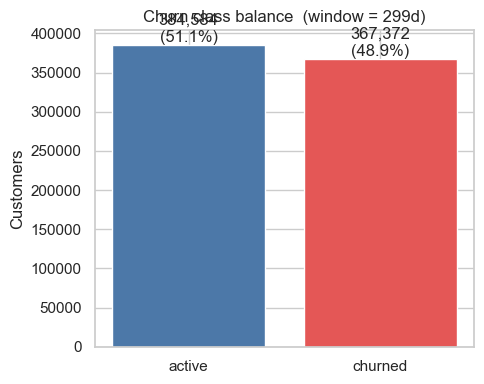

In [5]:
bal = class_balance(features)
print(bal)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["active", "churned"], [bal["n_active"], bal["n_churned"]], color=["#4C78A8", "#E45756"])
for i, v in enumerate([bal["n_active"], bal["n_churned"]]):
    ax.text(i, v, f"{v:,}\n({v/bal['n']:.1%})", ha="center", va="bottom")
ax.set_ylabel("Customers")
ax.set_title(f"Churn class balance  (window = {CHURN_WINDOW_DAYS}d)")
plt.tight_layout()
plt.savefig("../docs/figures/features_class_balance.png", dpi=120)
plt.show()

## BG/NBD + Gamma-Gamma input distributions

One figure per modeling input.

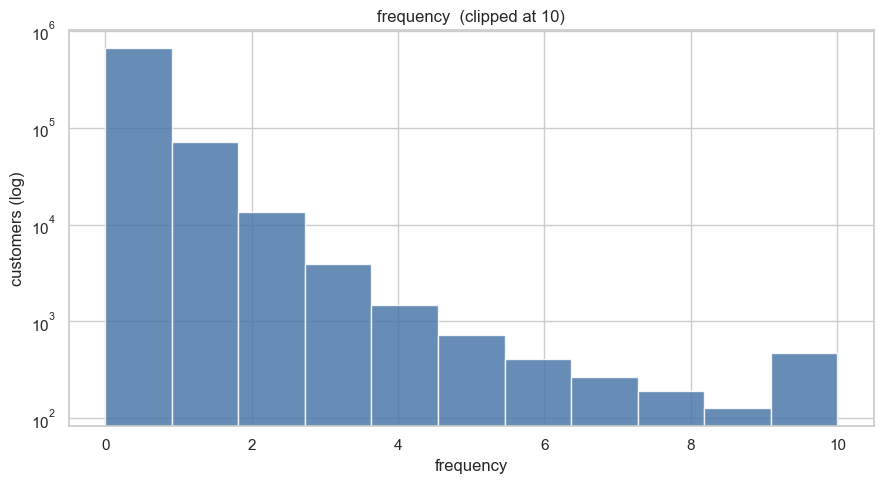

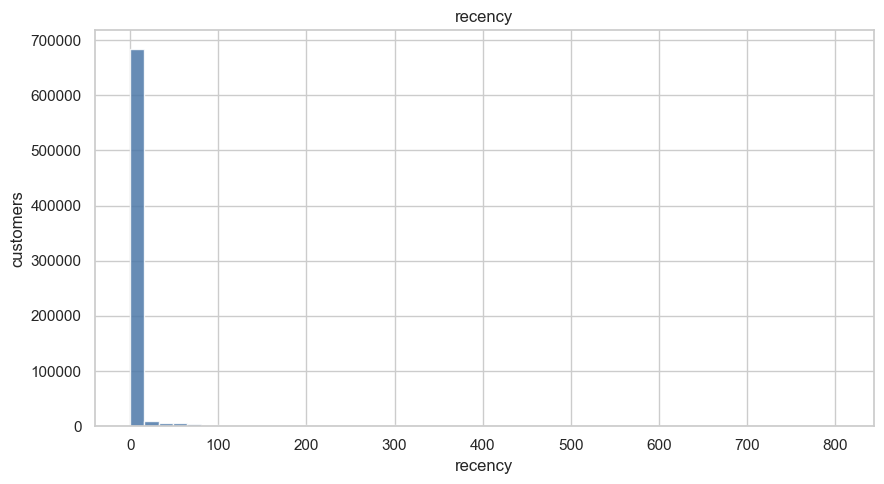

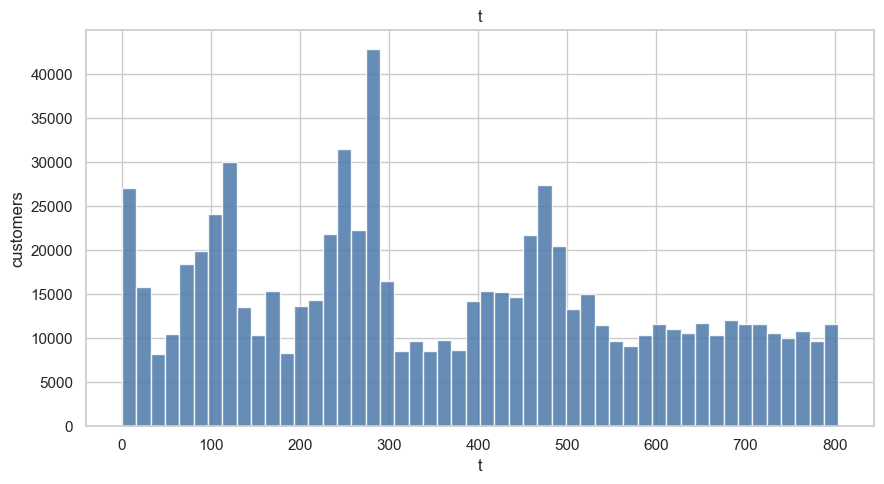

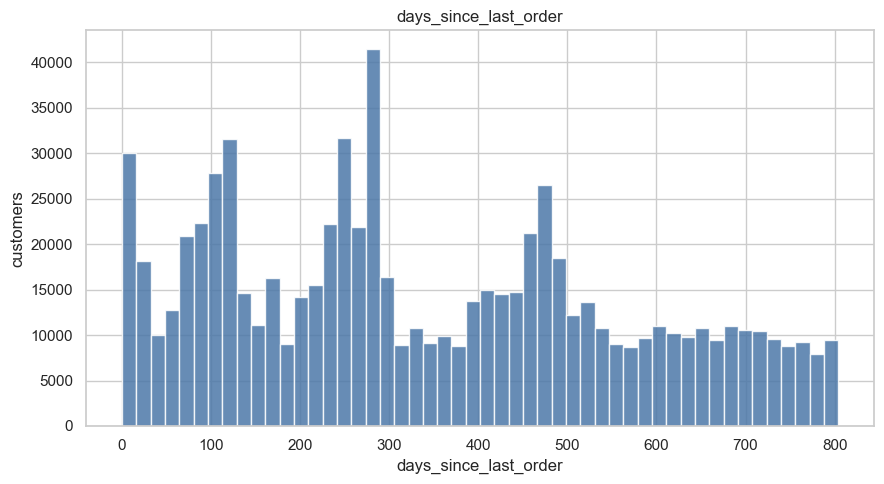

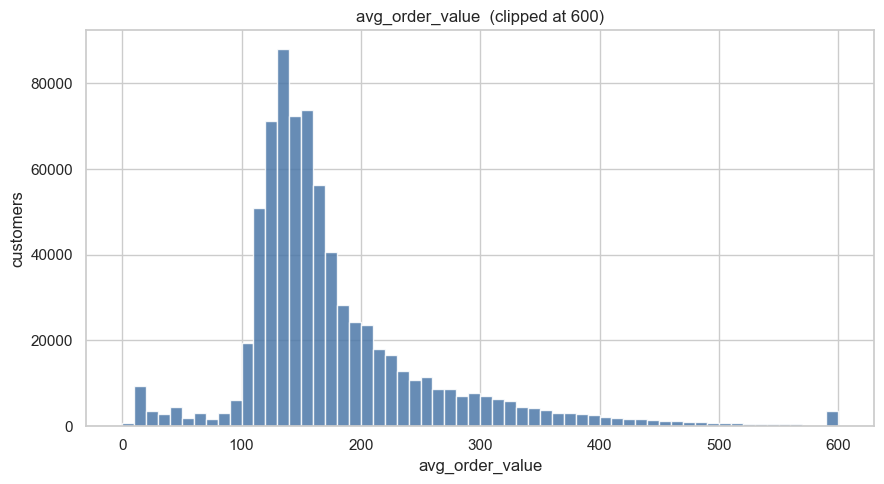

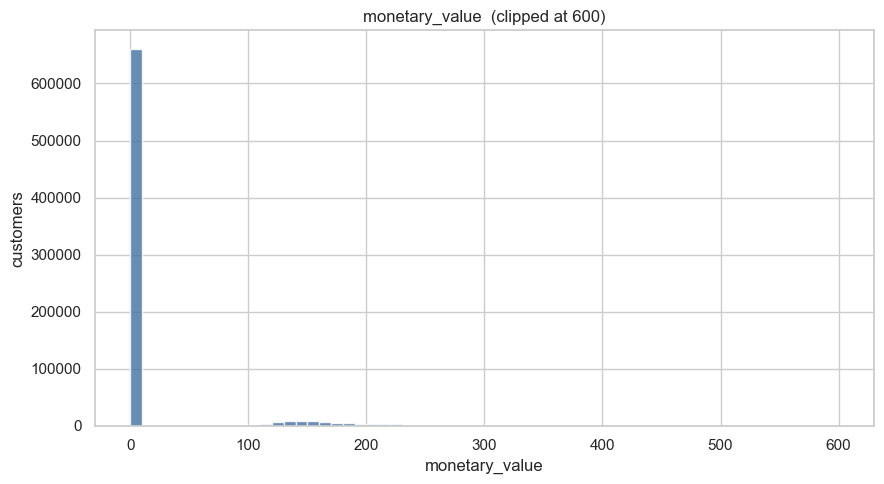

In [6]:
def hist(col, clip=None, bins=50, log=False):
    s = features[col].clip(upper=clip) if clip else features[col]
    fig, ax = plt.subplots()
    ax.hist(s, bins=bins, color="#4C78A8", alpha=0.85)
    if log:
        ax.set_yscale("log")
    title = col
    if clip:
        title += f"  (clipped at {clip})"
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("customers (log)" if log else "customers")
    plt.tight_layout()
    plt.savefig(f"../docs/figures/features_{col}.png", dpi=120)
    plt.show()

hist("frequency", clip=10, bins=11, log=True)
hist("recency", bins=50)              # BG/NBD recency = last - first
hist("t", bins=50)                     # BG/NBD T = snapshot - first
hist("days_since_last_order", bins=50) # snapshot recency (drives churn label)
hist("avg_order_value", clip=600, bins=60)
hist("monetary_value", clip=600, bins=60)  # Gamma-Gamma input

## Recency vs tenure (BG/NBD invariant check)

Every point should lie on or below the diagonal — `recency <= t`.

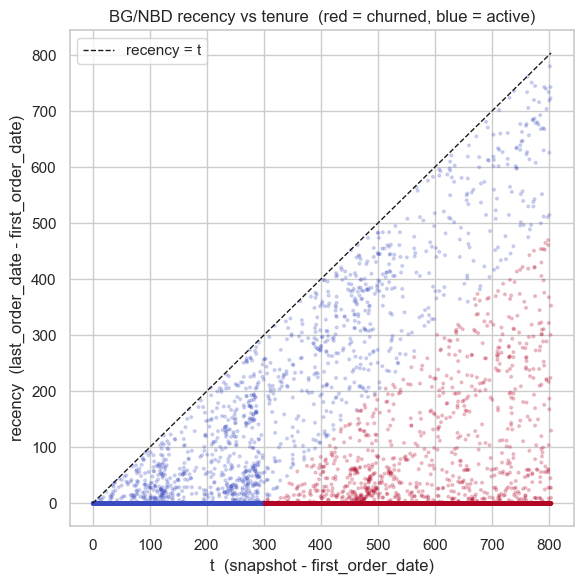

In [7]:
sample = features.sample(min(20000, len(features)), random_state=0)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sample["t"], sample["recency"], s=4, alpha=0.2, c=sample["is_churned"], cmap="coolwarm")
lim = max(features["t"].max(), features["recency"].max())
ax.plot([0, lim], [0, lim], "k--", linewidth=1, label="recency = t")
ax.set_xlabel("t  (snapshot - first_order_date)")
ax.set_ylabel("recency  (last_order_date - first_order_date)")
ax.set_title("BG/NBD recency vs tenure  (red = churned, blue = active)")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/figures/features_recency_vs_t.png", dpi=120)
plt.show()

## Feature correlations  (multicollinearity hint for M2)

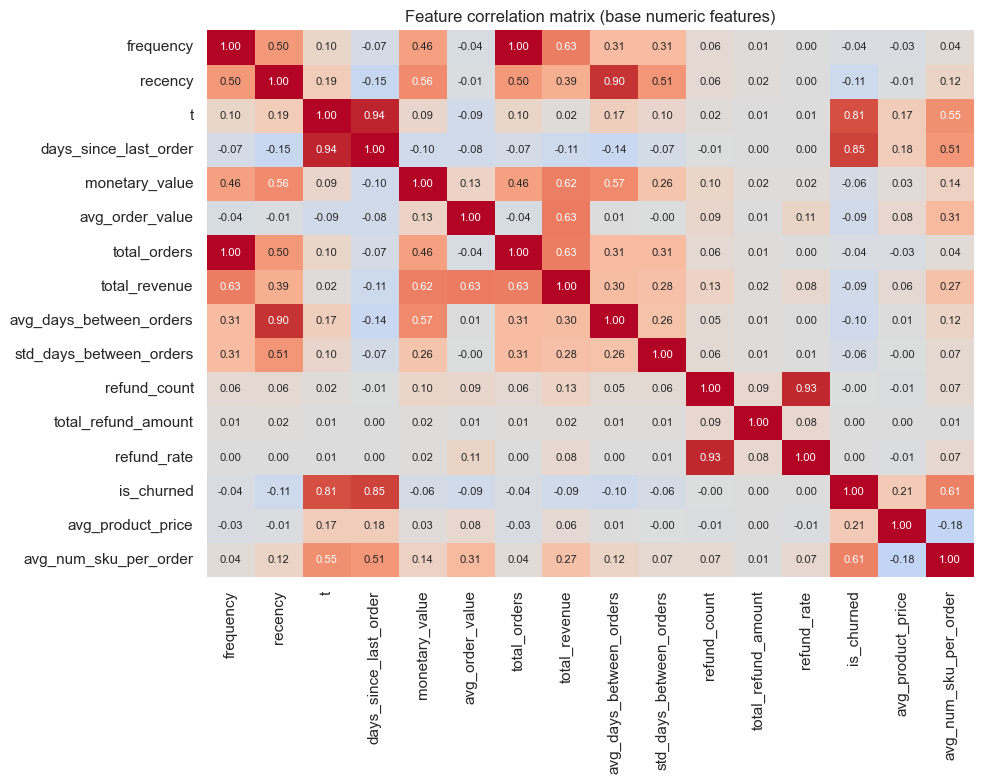

In [8]:
BASE_COLS = [c for c in features.select_dtypes(include="number").columns
             if not c.startswith(("log_", "ptype_", "pricebucket_", "gender_", "region_",
                                   "bgnbd_", "orders_last_", "revenue_last_"))]
corr = features[BASE_COLS].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar=False, annot_kws={"size": 8})
ax.set_title("Feature correlation matrix (base numeric features)")
plt.tight_layout()
plt.savefig("../docs/figures/features_correlations.png", dpi=120)
plt.show()

## Revenue Pareto  &  Days-Since CDF

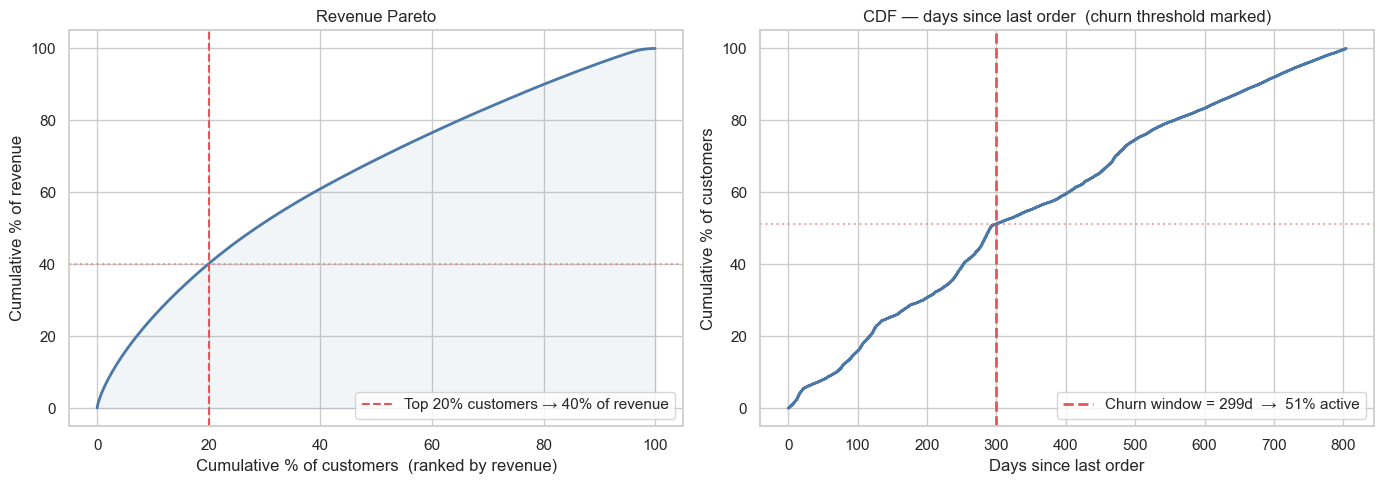

Top 20% of customers drive 40% of revenue
51% of customers ordered within the 299-day window (= 'active')


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Revenue Pareto ---
rev_sorted = features["total_revenue"].sort_values(ascending=False).reset_index(drop=True)
cum_cust   = np.linspace(0, 100, len(rev_sorted))
cum_rev    = rev_sorted.cumsum() / rev_sorted.sum() * 100
top20_rev  = float(pd.Series(cum_rev).iloc[int(len(rev_sorted) * 0.20)])

axes[0].plot(cum_cust, cum_rev, color="#4C78A8", lw=2)
axes[0].fill_between(cum_cust, cum_rev, alpha=0.07, color="#4C78A8")
axes[0].axvline(20, color="#E45756", ls="--", lw=1.5,
                label=f"Top 20% customers → {top20_rev:.0f}% of revenue")
axes[0].axhline(top20_rev, color="#E45756", ls=":", alpha=0.5)
axes[0].set_xlabel("Cumulative % of customers  (ranked by revenue)")
axes[0].set_ylabel("Cumulative % of revenue")
axes[0].set_title("Revenue Pareto")
axes[0].legend(loc="lower right")

# --- Days-since-last-order CDF with churn threshold ---
dsl        = features["days_since_last_order"].sort_values().values
cdf_pct    = np.arange(1, len(dsl) + 1) / len(dsl) * 100
active_pct = float((features["days_since_last_order"] <= CHURN_WINDOW_DAYS).mean() * 100)

axes[1].plot(dsl, cdf_pct, color="#4C78A8", lw=2)
axes[1].axvline(CHURN_WINDOW_DAYS, color="#E45756", ls="--", lw=2,
                label=f"Churn window = {CHURN_WINDOW_DAYS}d  →  {active_pct:.0f}% active")
axes[1].axhline(active_pct, color="#E45756", ls=":", alpha=0.5)
axes[1].set_xlabel("Days since last order")
axes[1].set_ylabel("Cumulative % of customers")
axes[1].set_title("CDF — days since last order  (churn threshold marked)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../docs/figures/features_pareto_dsl_cdf.png", dpi=120)
plt.show()
print(f"Top 20% of customers drive {top20_rev:.0f}% of revenue")
print(f"{active_pct:.0f}% of customers ordered within the {CHURN_WINDOW_DAYS}-day window (= 'active')")

## Acceptance criteria
- [x] `feature_table_v2.parquet` loads without errors
- [x] Class balance chart — churn rate and absolute counts visible
- [x] Distribution figures for every BG/NBD input (`frequency`, `recency`, `t`, `days_since_last_order`, `monetary_value`, `avg_order_value`)
- [x] BG/NBD recency ≤ t invariant confirmed (scatter, all points on or below diagonal)
- [x] Feature correlation heatmap (base numeric columns only — robust to extra derived columns)
- [x] Revenue Pareto — top 20% customer share of total revenue printed
- [x] Days-since CDF with 299-day churn threshold marked
- [x] All figures saved to `docs/figures/`